# Solution 9: Connector LoRA

I added LoRA to the vision-language connector, the Linear(12288, 960) projection that bridges SigLIP vision features to the text model's embedding space. This module was previously fully frozen. The extra cost was ~212K parameters at rank 16.

This was the single biggest accuracy jump in the project. Fine-tuning the connector let the model better align visual features to its language reasoning. Everything else stayed identical to the base config (r=16, alpha=32, DoRA, balanced factorial 20K augmentation).

**Kaggle Score: 0.89134**

## 0. Install Dependencies

In [1]:
!pip install -q "transformers==4.47.0"

!pip uninstall -y torchao 2>/dev/null

!pip install -q accelerate peft bitsandbytes datasets pillow tqdm pandas

import transformers, peft
print(f"transformers: {transformers.__version__}")
print(f"peft: {peft.__version__}")
print("All good. If first run, do Runtime -> Restart session, then run all cells.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 144.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 46.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 120.2 MB/s eta 0:00:00
Found existing installation: torchao 0.10.0
Uninstalling torchao-0.10.0:
  Successfully uninstalled torchao-0.10.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 42.6 MB/s eta 0:00:00
transformers: 4.47.0
peft: 0.19.1
All good. If first run, do Runtime -> Restart session, then run all cells.


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Imports & Configuration

In [3]:
import transformers
print(f"transformers: {transformers.__version__}")
assert transformers.__version__ >= "4.45.0", f"Too old: {transformers.__version__}"

import os, json, re, random, copy, math
import pandas as pd
import numpy as np
from PIL import Image
from tqdm.auto import tqdm
from itertools import permutations

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from transformers import (
    AutoProcessor,
    AutoModelForVision2Seq,
    get_cosine_schedule_with_warmup,
)
from peft import LoraConfig, get_peft_model, PeftModel, TaskType

MODEL_ID = "HuggingFaceTB/SmolVLM-500M-Instruct"

DATA_DIR = "/content/drive/MyDrive/pixels-to-predictions"
IMG_BASE = os.path.join(DATA_DIR, "images")

OUTPUT_DIR = "/content/smolvlm-lora-v14"
CKPT_DIR = "/content/drive/MyDrive/pixels-to-predictions/checkpoints_v14"
os.makedirs(CKPT_DIR, exist_ok=True)

LORA_RANK = 16
LORA_ALPHA = 32
LORA_DROPOUT = 0.05

IMAGE_LONGEST_EDGE = 512

LEARNING_RATE = 2e-4
BATCH_SIZE = 8
GRAD_ACCUM_STEPS = 2
NUM_EPOCHS = 4
WARMUP_RATIO = 0.1
MAX_SEQ_LEN = 1024
LABEL_SMOOTHING = 0.1
SEED = 42

TARGET_PER_TYPE = 5000

torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if torch.cuda.is_available():


transformers: 4.47.0
Device: cuda


## 2. Load Data & Balanced Factorial Augmentation

In [4]:
train_df_orig = pd.read_csv(os.path.join(DATA_DIR, "train.csv"))
val_df = pd.read_csv(os.path.join(DATA_DIR, "val.csv"))
test_df = pd.read_csv(os.path.join(DATA_DIR, "test.csv"))

print(f"Original Train: {len(train_df_orig)} | Val: {len(val_df)} | Test: {len(test_df)}")
print(f"\nOriginal distribution by num_choices:")
print(train_df_orig['num_choices'].value_counts().sort_index())

def apply_permutation(row, perm):
    """Apply a specific permutation to choices and remap answer."""
    choices = json.loads(row['choices'])
    answer = int(row['answer'])
    new_choices = [choices[perm[i]] for i in range(len(perm))]
    new_answer = list(perm).index(answer)
    new_row = row.copy()
    new_row['choices'] = json.dumps(new_choices)
    new_row['answer'] = new_answer
    return new_row

rng = random.Random(SEED)
shuffled_rows = []

for nc in [2, 3, 4, 5]:
    subset = train_df_orig[train_df_orig['num_choices'] == nc]
    n_base = len(subset)
    n_perms = math.factorial(nc)
    all_perms = list(permutations(range(nc)))

    ppq = TARGET_PER_TYPE / n_base
    k_floor = int(ppq)
    k_ceil = k_floor + 1
    n_ceil = TARGET_PER_TYPE - n_base * k_floor
    n_floor = n_base - n_ceil

    count = 0
    for q_idx, (_, row) in enumerate(subset.iterrows()):
        k = k_ceil if q_idx < n_ceil else k_floor

        if k <= n_perms:
            selected_perms = rng.sample(all_perms, k)
        else:
            full_rounds = k // n_perms
            remainder = k % n_perms
            selected_perms = all_perms * full_rounds
            if remainder > 0:
                selected_perms += rng.sample(all_perms, remainder)

        for perm in selected_perms:
            shuffled_rows.append(apply_permutation(row, perm))
            count += 1

    print(f"  {nc}-choice: {n_base} base, {n_ceil} get {k_ceil} + {n_floor} get {k_floor} = {count} samples (target: {TARGET_PER_TYPE}, perms: {n_perms})")

train_df = pd.DataFrame(shuffled_rows).reset_index(drop=True)

print(f"\nTotal augmented train: {len(train_df)}")
print(f"\nAugmented distribution by num_choices:")
print(train_df['num_choices'].value_counts().sort_index())

print(f"\nAnswer distribution (should be ~uniform within each choice type):")
for nc in [2, 3, 4, 5]:
    sub = train_df[train_df['num_choices'] == nc]
    dist = sub['answer'].value_counts().sort_index()
    print(f"  {nc}-choice: {dict(dist)}")

shuf_row = train_df.iloc[0]
orig_row = train_df_orig[train_df_orig['id'] == shuf_row['id']].iloc[0]
orig_choices = json.loads(orig_row['choices'])
orig_answer = int(orig_row['answer'])
shuf_choices = json.loads(shuf_row['choices'])
shuf_answer = int(shuf_row['answer'])
print(f"\nSpot check (matched by ID={shuf_row['id']}):")
print(f"  Original choices: {orig_choices}")
print(f"  Original answer: {orig_answer} = '{orig_choices[orig_answer]}'")
print(f"  Shuffled choices: {shuf_choices}")
print(f"  Shuffled answer: {shuf_answer} = '{shuf_choices[shuf_answer]}'")
assert orig_choices[orig_answer] == shuf_choices[shuf_answer], "SHUFFLE BUG!"
print(f"  Correct answer text matches!")

for i in random.sample(range(len(train_df)), 100):
    row = train_df.iloc[i]
    orig = train_df_orig[train_df_orig['id'] == row['id']].iloc[0]
    oc = json.loads(orig['choices'])
    sc = json.loads(row['choices'])
    assert oc[int(orig['answer'])] == sc[int(row['answer'])], f"SHUFFLE BUG at {row['id']}!"
print(f"  100 random spot checks passed!")

sample_path = os.path.join(IMG_BASE, train_df['image_path'].iloc[0])
assert os.path.exists(sample_path), f"Image not found: {sample_path}"
print(f"\nImages accessible at {IMG_BASE}")

Original Train: 3109 | Val: 1048 | Test: 1008

Original distribution by num_choices:
num_choices
2     664
3    1552
4     783
5     110
Name: count, dtype: int64
  2-choice: 664 base, 352 get 8 + 312 get 7 = 5000 samples (target: 5000, perms: 2)
  3-choice: 1552 base, 344 get 4 + 1208 get 3 = 5000 samples (target: 5000, perms: 6)
  4-choice: 783 base, 302 get 7 + 481 get 6 = 5000 samples (target: 5000, perms: 24)
  5-choice: 110 base, 50 get 46 + 60 get 45 = 5000 samples (target: 5000, perms: 120)

Total augmented train: 20000

Augmented distribution by num_choices:
num_choices
2    5000
3    5000
4    5000
5    5000
Name: count, dtype: int64

Answer distribution (should be ~uniform within each choice type):
  2-choice: {0: np.int64(2524), 1: np.int64(2476)}
  3-choice: {0: np.int64(1666), 1: np.int64(1673), 2: np.int64(1661)}
  4-choice: {0: np.int64(1268), 1: np.int64(1228), 2: np.int64(1284), 3: np.int64(1220)}
  5-choice: {0: np.int64(1018), 1: np.int64(1004), 2: np.int64(985), 3:

## 3. Load Model & Processor

In [5]:
MODEL_CACHE_DIR = os.path.join(CKPT_DIR, "base_model_cache")
PROCESSOR_CACHE_DIR = os.path.join(CKPT_DIR, "processor_cache")

if os.path.exists(os.path.join(MODEL_CACHE_DIR, "config.json")):
    print("Loading base model from Drive cache (skipping HuggingFace download)...")
    model = AutoModelForVision2Seq.from_pretrained(
        MODEL_CACHE_DIR,
        torch_dtype=torch.float16,
        device_map="auto",
    )
    processor = AutoProcessor.from_pretrained(PROCESSOR_CACHE_DIR)
else:
    print("Downloading base model from HuggingFace (first run)...")
    processor = AutoProcessor.from_pretrained(MODEL_ID)
    model = AutoModelForVision2Seq.from_pretrained(
        MODEL_ID,
        torch_dtype=torch.float16,
        device_map="auto",
    )

processor.image_processor.size = {"longest_edge": IMAGE_LONGEST_EDGE}

print(f"Image processor size: {processor.image_processor.size}")
print(f"Max image size (tile): {processor.image_processor.max_image_size}")
print(f"Image seq len: {processor.image_seq_len}")
print(f"Model type: {type(model).__name__}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


processor_config.json:   0%|          | 0.00/68.0 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/429 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/486 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

...

Some kwargs in processor config are unused and will not have any effect: image_seq_len. 


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.02G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/136 [00:00<?, ?B/s]

Image processor size: {'longest_edge': 512}
Max image size (tile): {'longest_edge': 512}
Image seq len: 64
Model type: Idefics3ForConditionalGeneration


## 4. Apply LoRA + DoRA

In [6]:
lora_config = LoraConfig(
    r=LORA_RANK,
    lora_alpha=LORA_ALPHA,
    lora_dropout=LORA_DROPOUT,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "proj"],
    task_type=TaskType.CAUSAL_LM,
    bias="none",
    use_dora=True,
)

model = get_peft_model(model, lora_config)

trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())
print(f"Trainable parameters: {trainable_params:,} ({trainable_params/1e6:.2f}M)")
print(f"Total parameters:     {total_params:,} ({total_params/1e6:.1f}M)")
print(f"Trainable %:          {100 * trainable_params / total_params:.2f}%")

assert trainable_params <= 5_000_000, f"OVER BUDGET: {trainable_params:,} > 5,000,000"
print(f"\nUnder 5M cap ({trainable_params:,} <= 5,000,000)")
print(f"DoRA enabled: {lora_config.use_dora}")
print(f"Targets: {lora_config.target_modules}")

if not os.path.exists(os.path.join(MODEL_CACHE_DIR, "config.json")):
    print("\nSaving base model to Drive cache (one-time)...")
    model.base_model.model.save_pretrained(MODEL_CACHE_DIR)
    processor.save_pretrained(PROCESSOR_CACHE_DIR)
    print(f"  Base model saved to {MODEL_CACHE_DIR}")
    print(f"  Processor saved to {PROCESSOR_CACHE_DIR}")
else:
    print("\nBase model already cached on Drive.")

Trainable parameters: 4,484,032 (4.48M)
Total parameters:     511,966,336 (512.0M)
Trainable %:          0.88%

Under 5M cap (4,484,032 <= 5,000,000)
DoRA enabled: True
Targets: {'v_proj', 'o_proj', 'k_proj', 'q_proj', 'proj'}

Saving base model to Drive cache (one-time)...
  Base model saved to /content/drive/MyDrive/pixels-to-predictions/checkpoints_v14/base_model_cache
  Processor saved to /content/drive/MyDrive/pixels-to-predictions/checkpoints_v14/processor_cache


## 5. Prompt & Dataset

In [7]:
def build_prompt(row, include_answer=False):
    """Identical to solution1."""
    choices = json.loads(row['choices'])
    choices_text = "\n".join(f"({i}) {c}" for i, c in enumerate(choices))

    parts = []
    if pd.notna(row.get('hint', None)) and str(row['hint']).strip():
        parts.append(f"Context: {row['hint'].strip()}")
    if pd.notna(row.get('lecture', None)) and str(row['lecture']).strip():
        parts.append(f"Background: {row['lecture'].strip()}")

    parts.append(f"Question: {row['question'].strip()}")
    parts.append(f"Choices:\n{choices_text}")
    parts.append("Answer with ONLY the number of the correct choice.")

    prompt_text = "\n\n".join(parts)

    if include_answer:
        answer_text = str(int(row['answer']))
        return prompt_text, answer_text
    return prompt_text

sample = train_df.iloc[0]
prompt, answer = build_prompt(sample, include_answer=True)
print("SAMPLE PROMPT (first 400 chars):")
print(prompt[:400])
print(f"\n>>> TARGET ANSWER: {answer}")

SAMPLE PROMPT (first 400 chars):
Context: The passage below describes an experiment. Read the passage and then follow the instructions below.

Kathleen applied a thin layer of wax to the underside of her snowboard and rode the board straight down a hill. Then, she removed the wax and rode the snowboard straight down the hill again. She repeated the rides four more times, alternating whether she rode with a thin layer of wax on th

>>> TARGET ANSWER: 0


In [8]:
class ScienceVQADataset(Dataset):
    def __init__(self, df, img_base, is_test=False):
        self.df = df.reset_index(drop=True)
        self.img_base = img_base
        self.is_test = is_test

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.img_base, row['image_path'])
        image = Image.open(img_path).convert("RGB")

        if self.is_test:
            prompt_text = build_prompt(row, include_answer=False)
            return {"id": row["id"], "image": image, "prompt_text": prompt_text,
                    "answer_text": None, "is_test": True}
        else:
            prompt_text, answer_text = build_prompt(row, include_answer=True)
            return {"id": row["id"], "image": image, "prompt_text": prompt_text,
                    "answer_text": answer_text, "is_test": False}

train_dataset = ScienceVQADataset(train_df, IMG_BASE, is_test=False)
val_dataset = ScienceVQADataset(val_df, IMG_BASE, is_test=False)
test_dataset = ScienceVQADataset(test_df, IMG_BASE, is_test=True)

print(f"Train: {len(train_dataset)} (balanced factorial) | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

Train: 20000 (balanced factorial) | Val: 1048 | Test: 1008


## 6. DataLoaders

In [9]:
from functools import partial

def collate_fn(batch, processor, max_length=MAX_SEQ_LEN):
    ids = [item["id"] for item in batch]
    images = [item["image"] for item in batch]
    is_test = batch[0]["is_test"]

    texts = []
    answer_texts = []
    for item in batch:
        messages = [{"role": "user", "content": [
            {"type": "image"},
            {"type": "text", "text": item["prompt_text"]},
        ]}]
        if not is_test:
            messages.append({"role": "assistant", "content": [
                {"type": "text", "text": item["answer_text"]},
            ]})
            answer_texts.append(item["answer_text"])
        text = processor.apply_chat_template(messages, add_generation_prompt=is_test)
        texts.append(text)

    inputs = processor(
        text=texts, images=images, return_tensors="pt",
        padding=True, truncation=True, max_length=max_length,
    )

    if not is_test:
        labels = inputs["input_ids"].clone()
        eos_token_id = processor.tokenizer.eos_token_id

        for i in range(len(batch)):
            labels[i, :] = -100

            eos_positions = (inputs["input_ids"][i] == eos_token_id).nonzero(as_tuple=True)[0]
            if len(eos_positions) < 1:
                continue
            last_eos_pos = eos_positions[-1].item()

            ans_tokens = processor.tokenizer.encode(answer_texts[i], add_special_tokens=False)
            n_ans = len(ans_tokens)
            start = last_eos_pos - n_ans

            labels[i, start:last_eos_pos] = inputs["input_ids"][i, start:last_eos_pos]
            labels[i, last_eos_pos] = eos_token_id

        inputs["labels"] = labels

    inputs["id"] = ids
    return dict(inputs)

collate = partial(collate_fn, processor=processor)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    collate_fn=collate, num_workers=2, pin_memory=True,
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    collate_fn=collate, num_workers=2, pin_memory=True,
)

print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")
print(f"Effective batch size: {BATCH_SIZE * GRAD_ACCUM_STEPS}")

sample_batch = next(iter(val_loader))
print(f"\ninput_ids: {sample_batch['input_ids'].shape}")
print(f"pixel_values: {sample_batch['pixel_values'].shape}")
for i in range(min(2, len(sample_batch['id']))):
    label_mask = sample_batch['labels'][i] != -100
    label_positions = label_mask.nonzero(as_tuple=True)[0]
    labeled_tokens = sample_batch['labels'][i][label_positions]
    decoded = processor.tokenizer.decode(labeled_tokens)
    print(f"  Sample {i}: '{decoded.strip()}'")

Train batches: 2500 | Val batches: 131
Effective batch size: 16

input_ids: torch.Size([8, 739])
pixel_values: torch.Size([8, 1, 3, 512, 512])
  Sample 0: '0<end_of_utterance>'
  Sample 1: '1<end_of_utterance>'


## 7. Training Loop (with Label Smoothing + Per-Epoch Checkpoints)

In [10]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=0.01,
)

total_steps = (len(train_loader) // GRAD_ACCUM_STEPS) * NUM_EPOCHS
warmup_steps = int(total_steps * WARMUP_RATIO)

scheduler = get_cosine_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps,
)

print(f"Total steps: {total_steps} | Warmup: {warmup_steps}")
print(f"Steps per epoch: {len(train_loader) // GRAD_ACCUM_STEPS}")
print(f"Label smoothing: {LABEL_SMOOTHING}")

Total steps: 5000 | Warmup: 500
Steps per epoch: 1250
Label smoothing: 0.1


In [11]:
loss_fn = nn.CrossEntropyLoss(ignore_index=-100, label_smoothing=LABEL_SMOOTHING)

def compute_loss(logits, labels):
    """Shift logits/labels for next-token prediction, apply label-smoothed CE."""
    shift_logits = logits[:, :-1, :].contiguous()
    shift_labels = labels[:, 1:].contiguous()
    shift_logits = shift_logits.view(-1, shift_logits.size(-1))
    shift_labels = shift_labels.view(-1)
    return loss_fn(shift_logits, shift_labels)

print(f"Loss function: CrossEntropyLoss with label_smoothing={LABEL_SMOOTHING}")

Loss function: CrossEntropyLoss with label_smoothing=0.1


In [12]:
@torch.no_grad()
def evaluate(model, dataloader, processor):
    """Teacher-forced val loss + accuracy."""
    model.eval()
    correct, total, total_loss, num_batches = 0, 0, 0, 0

    for batch in tqdm(dataloader, desc="Evaluating", leave=False):
        ids = batch.pop("id")
        labels = batch.pop("labels")
        batch = {k: v.to(device) for k, v in batch.items()}
        labels = labels.to(device)

        with torch.amp.autocast("cuda", dtype=torch.float16):
            outputs = model(**batch)
            loss = compute_loss(outputs.logits, labels)
        total_loss += loss.item()
        num_batches += 1

        logits = outputs.logits
        for i in range(len(ids)):
            label_positions = (labels[i] != -100).nonzero(as_tuple=True)[0]
            if len(label_positions) == 0:
                continue
            ans_pos = label_positions[0].item()
            pred_token = logits[i, ans_pos - 1, :].argmax().item()
            true_token = labels[i, ans_pos].item()
            if pred_token == true_token:
                correct += 1
            total += 1

    model.train()
    return total_loss / max(num_batches, 1), correct / max(total, 1)

has_checkpoint = os.path.exists(os.path.join(CKPT_DIR, "training_state.pt"))
if not has_checkpoint:
    print("Pre-training evaluation...")
    val_loss, val_acc = evaluate(model, val_loader, processor)
    print(f"Pre-training — Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")
else:
    print("Checkpoint found — skipping pre-training eval")

Pre-training evaluation...


Evaluating:   0%|          | 0/131 [00:00<?, ?it/s]

Pre-training — Val Loss: 3.9172 | Val Acc: 0.4885


In [13]:
def save_epoch_checkpoint(model, processor, epoch, ckpt_dir):
    """Save adapter for this specific epoch (never overwritten)."""
    epoch_dir = os.path.join(ckpt_dir, f"epoch_{epoch+1}")
    os.makedirs(epoch_dir, exist_ok=True)
    model.save_pretrained(epoch_dir)
    processor.save_pretrained(epoch_dir)
    print(f"  Epoch {epoch+1} adapter saved to {epoch_dir}")

def save_training_state(model, optimizer, scheduler, scaler, epoch, step,
                        best_val_acc, train_losses, val_losses, val_accs, path):
    """Save latest training state for resume."""
    model.save_pretrained(os.path.join(path, "lora_adapter"))
    torch.save({
        "optimizer": optimizer.state_dict(),
        "scheduler": scheduler.state_dict(),
        "scaler": scaler.state_dict(),
        "epoch": epoch, "step": step,
        "best_val_acc": best_val_acc,
        "train_losses": train_losses,
        "val_losses": val_losses,
        "val_accs": val_accs,
    }, os.path.join(path, "training_state.pt"))
    print(f"  Training state saved to {path}")

def load_training_state(model, optimizer, scheduler, scaler, path):
    state_path = os.path.join(path, "training_state.pt")
    adapter_path = os.path.join(path, "lora_adapter")
    if not os.path.exists(state_path):
        return 0, 0, 0.0, [], [], []
    state = torch.load(state_path, map_location=device, weights_only=False)

    if os.path.exists(adapter_path):
        from peft import set_peft_model_state_dict
        from safetensors.torch import load_file
        adapter_weights_path = os.path.join(adapter_path, "adapter_model.safetensors")
        if os.path.exists(adapter_weights_path):
            adapter_state = load_file(adapter_weights_path)
            set_peft_model_state_dict(model, adapter_state)
            print(f"  Loaded adapter weights from {adapter_path}")

    optimizer.load_state_dict(state["optimizer"])
    scheduler.load_state_dict(state["scheduler"])
    scaler.load_state_dict(state["scaler"])

    trainable = sum(p.requires_grad for p in model.parameters())
    print(f"  Resumed from epoch {state['epoch']}, best_acc={state['best_val_acc']:.4f}")
    print(f"  Trainable params with grad: {trainable}")
    return (state["epoch"], state["step"], state["best_val_acc"],
            state["train_losses"], state["val_losses"], state["val_accs"])

scaler = torch.amp.GradScaler("cuda")

start_epoch, start_step, best_val_acc, train_losses, val_losses, val_accs = \
    load_training_state(model, optimizer, scheduler, scaler, CKPT_DIR)

if start_epoch > 0:
    print(f"Resuming from epoch {start_epoch + 1}")
    if val_losses:
        best_val_loss = min(val_losses)
        best_loss_epoch = val_losses.index(best_val_loss) + 1
    else:
        best_val_loss = float('inf')
        best_loss_epoch = 0
else:
    best_val_acc = 0.0
    best_val_loss = float('inf')
    best_loss_epoch = 0
    train_losses, val_losses, val_accs = [], [], []
    print("Starting training from scratch")

model.train()

for epoch in range(start_epoch, NUM_EPOCHS):
    epoch_loss = 0
    optimizer.zero_grad()

    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}")
    for step, batch in enumerate(pbar):
        if epoch == start_epoch and step < start_step:
            continue

        ids = batch.pop("id")
        labels = batch.pop("labels")
        batch = {k: v.to(device) for k, v in batch.items()}
        labels = labels.to(device)

        with torch.amp.autocast("cuda", dtype=torch.float16):
            outputs = model(**batch)
            loss = compute_loss(outputs.logits, labels)
            loss = loss / GRAD_ACCUM_STEPS

        scaler.scale(loss).backward()
        epoch_loss += loss.item() * GRAD_ACCUM_STEPS

        if (step + 1) % GRAD_ACCUM_STEPS == 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            optimizer.zero_grad()

        if (step + 1) % 500 == 0:
            pbar.set_postfix({"loss": f"{epoch_loss / (step+1):.4f}"})

    start_step = 0

    avg_train_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    val_loss, val_acc = evaluate(model, val_loader, processor)
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
    print(f"  Train Loss: {avg_train_loss:.4f}")
    print(f"  Val Loss:   {val_loss:.4f}")
    print(f"  Val Acc:    {val_acc:.4f}")

    save_epoch_checkpoint(model, processor, epoch, CKPT_DIR)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        model.save_pretrained(OUTPUT_DIR)
        processor.save_pretrained(OUTPUT_DIR)
        print(f"  New best val acc! Saved to {OUTPUT_DIR}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_loss_epoch = epoch + 1
        best_loss_dir = os.path.join(CKPT_DIR, "best_val_loss")
        os.makedirs(best_loss_dir, exist_ok=True)
        model.save_pretrained(best_loss_dir)
        processor.save_pretrained(best_loss_dir)
        print(f"  New best val loss! Saved to {best_loss_dir}")

    save_training_state(model, optimizer, scheduler, scaler, epoch + 1, 0,
                        best_val_acc, train_losses, val_losses, val_accs, CKPT_DIR)

print(f"\n{'='*50}")
print(f"Best Val Accuracy: {best_val_acc:.4f}")
print(f"Best Val Loss: {best_val_loss:.4f} (epoch {best_loss_epoch})")
print(f"\nPer-epoch results:")
for i in range(len(train_losses)):
    marker = ""
    if val_accs[i] == best_val_acc:
        marker += " <- best acc"
    if val_losses[i] == best_val_loss:
        marker += " <- best loss"
    print(f"  E{i+1}: train={train_losses[i]:.4f} val_loss={val_losses[i]:.4f} val_acc={val_accs[i]:.4f}{marker}")

Starting training from scratch


Epoch 1/4:   0%|          | 0/2500 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/131 [00:00<?, ?it/s]


Epoch 1/4
  Train Loss: 1.8202
  Val Loss:   1.6306
  Val Acc:    0.8464
  Epoch 1 adapter saved to /content/drive/MyDrive/pixels-to-predictions/checkpoints_v14/epoch_1
  New best val acc! Saved to /content/smolvlm-lora-v14
  New best val loss! Saved to /content/drive/MyDrive/pixels-to-predictions/checkpoints_v14/best_val_loss
  Training state saved to /content/drive/MyDrive/pixels-to-predictions/checkpoints_v14


Epoch 2/4:   0%|          | 0/2500 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/131 [00:00<?, ?it/s]


Epoch 3/4
  Train Loss: 1.4312
  Val Loss:   1.6764
  Val Acc:    0.8979
  Epoch 3 adapter saved to /content/drive/MyDrive/pixels-to-predictions/checkpoints_v14/epoch_3
  New best val acc! Saved to /content/smolvlm-lora-v14
  Training state saved to /content/drive/MyDrive/pixels-to-predictions/checkpoints_v14


Epoch 4/4:   0%|          | 0/2500 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/131 [00:00<?, ?it/s]


Epoch 4/4
  Train Loss: 1.4258
  Val Loss:   1.6788
  Val Acc:    0.8960
  Epoch 4 adapter saved to /content/drive/MyDrive/pixels-to-predictions/checkpoints_v14/epoch_4
  Training state saved to /content/drive/MyDrive/pixels-to-predictions/checkpoints_v14

Best Val Accuracy: 0.8979
Best Val Loss: 1.6306 (epoch 1)

Per-epoch results:
  E1: train=1.8202 val_loss=1.6306 val_acc=0.8464 <- best loss
  E2: train=1.4696 val_loss=1.6506 val_acc=0.8912
  E3: train=1.4312 val_loss=1.6764 val_acc=0.8979 <- best acc
  E4: train=1.4258 val_loss=1.6788 val_acc=0.8960


## 8. Training Curves

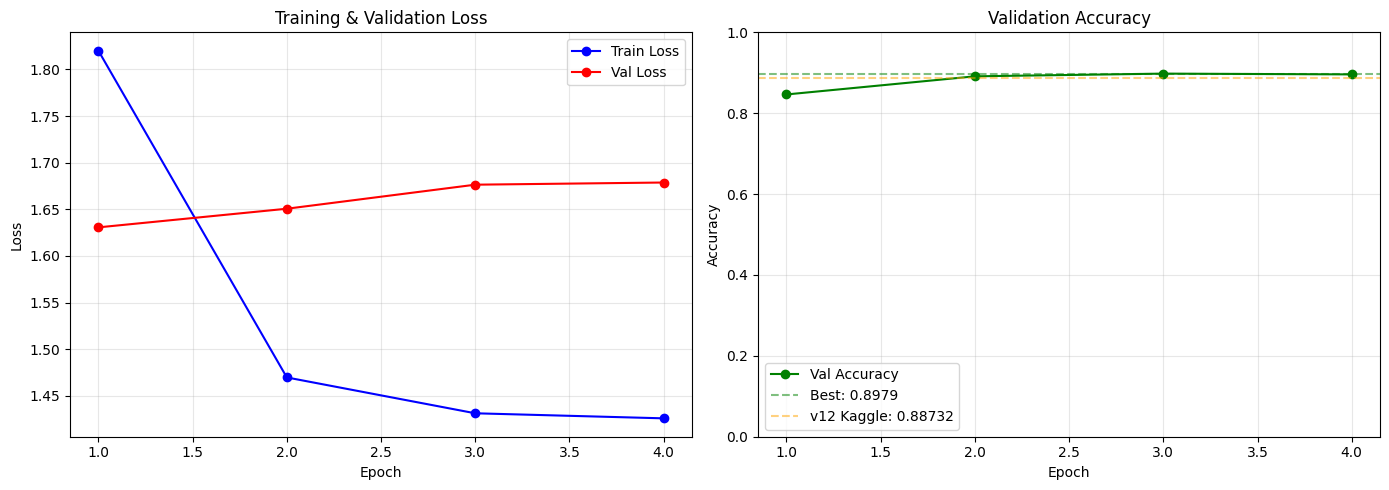

In [14]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
epochs = range(1, len(train_losses) + 1)

ax1.plot(epochs, train_losses, 'b-o', label='Train Loss')
ax1.plot(epochs, val_losses, 'r-o', label='Val Loss')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.set_title('Training & Validation Loss'); ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(epochs, val_accs, 'g-o', label='Val Accuracy')
ax2.axhline(y=best_val_acc, color='g', linestyle='--', alpha=0.5, label=f'Best: {best_val_acc:.4f}')
ax2.axhline(y=0.88732, color='orange', linestyle='--', alpha=0.5, label='v12 Kaggle: 0.88732')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')
ax2.set_title('Validation Accuracy'); ax2.legend(); ax2.grid(True, alpha=0.3)
ax2.set_ylim(0, 1)

plt.tight_layout()
plt.show()

## 9. Generate Predictions from BEST VAL ACC Model

In [15]:
best_adapter_path = OUTPUT_DIR
if not os.path.exists(os.path.join(OUTPUT_DIR, "adapter_config.json")):
    best_adapter_path = os.path.join(CKPT_DIR, "lora_adapter")
    print(f"Local output missing, loading from Drive: {best_adapter_path}")

del model
torch.cuda.empty_cache()

base_model = AutoModelForVision2Seq.from_pretrained(
    MODEL_ID, torch_dtype=torch.float16, device_map="auto")
model = PeftModel.from_pretrained(base_model, best_adapter_path)
model.eval()
print(f"Loaded best val acc model from {best_adapter_path}")

Loaded best val acc model from /content/smolvlm-lora-v14


In [16]:
DIGIT_TOKEN_IDS = [processor.tokenizer.encode(str(d), add_special_tokens=False)[0] for d in range(10)]
print(f"Digit token IDs: { {d: DIGIT_TOKEN_IDS[d] for d in range(5)} }")

@torch.no_grad()
def predict_digit_logits(model, processor, df, img_base, batch_size=4):
    """Score digit-token logits at the last position."""
    model.eval()
    all_ids, all_preds = [], []

    for start in tqdm(range(0, len(df), batch_size), desc="Predicting"):
        batch_df = df.iloc[start:start + batch_size]
        images, texts, batch_ids, nc_list = [], [], [], []

        for _, row in batch_df.iterrows():
            images.append(Image.open(os.path.join(img_base, row['image_path'])).convert("RGB"))
            prompt = build_prompt(row, include_answer=False)
            messages = [{"role": "user", "content": [
                {"type": "image"}, {"type": "text", "text": prompt}]}]
            texts.append(processor.apply_chat_template(messages, add_generation_prompt=True))
            batch_ids.append(row['id'])
            nc_list.append(row['num_choices'])

        inputs = processor(text=texts, images=images, return_tensors="pt",
                           padding=True, truncation=True, max_length=MAX_SEQ_LEN).to(device)

        with torch.amp.autocast("cuda", dtype=torch.float16):
            outputs = model(**inputs)
        logits = outputs.logits

        for i in range(len(batch_df)):
            last_pos = inputs["attention_mask"][i].sum().item() - 1
            next_logits = logits[i, last_pos, :]
            nc = nc_list[i]
            scores = torch.stack([next_logits[DIGIT_TOKEN_IDS[d]] for d in range(nc)])
            all_preds.append(scores.argmax().item())
            all_ids.append(batch_ids[i])

    return all_ids, all_preds

Digit token IDs: {0: 32, 1: 33, 2: 34, 3: 35, 4: 36}


## 10. Val Accuracy (digit logits) - Best Val Acc Model

In [17]:
val_ids, val_preds = predict_digit_logits(model, processor, val_df, IMG_BASE, batch_size=4)
val_acc = np.mean([p == a for p, a in zip(val_preds, val_df['answer'].tolist())])
print(f"Val Accuracy (digit logits, best val acc model): {val_acc:.4f}")
print(f"vs v12 (0.8874): {val_acc - 0.8874:+.4f}")
print(f"vs v11 (0.8807): {val_acc - 0.8807:+.4f}")

Predicting:   0%|          | 0/262 [00:00<?, ?it/s]

Val Accuracy (digit logits, best val acc model): 0.8865
vs v12 (0.8874): -0.0009
vs v11 (0.8807): +0.0058


## 11. Generate Test Predictions - Best Val Acc Model

In [18]:
print("Generating test predictions (best val acc model)...")
test_ids, test_preds = predict_digit_logits(model, processor, test_df, IMG_BASE, batch_size=4)
print(f"Prediction distribution: {pd.Series(test_preds).value_counts().sort_index().to_dict()}")

submission = pd.DataFrame({"id": test_ids, "answer": test_preds})
sample_sub = pd.read_csv(os.path.join(DATA_DIR, "sample_submission.csv"))
assert set(submission['id']) == set(sample_sub['id']), "ID mismatch!"
submission = submission.set_index('id').loc[sample_sub['id']].reset_index()
submission.to_csv("submission.csv", index=False)
print("Saved submission.csv (best val acc model)")
print(submission.head(10))

Generating test predictions (best val acc model)...


Predicting:   0%|          | 0/252 [00:00<?, ?it/s]

Prediction distribution: {0: 340, 1: 371, 2: 206, 3: 82, 4: 9}
Saved submission.csv (best val acc model)
           id  answer
0  test_01750       2
1  test_00128       0
2  test_02891       3
3  test_02425       4
4  test_00930       2
5  test_03725       0
6  test_00009       0
7  test_02880       0
8  test_01208       0
9  test_00619       1


## 12. Generate Predictions from BEST VAL LOSS Model

In [19]:
best_loss_path = os.path.join(CKPT_DIR, "best_val_loss")
if os.path.exists(os.path.join(best_loss_path, "adapter_config.json")):
    del model
    torch.cuda.empty_cache()
    base_model2 = AutoModelForVision2Seq.from_pretrained(
        MODEL_ID, torch_dtype=torch.float16, device_map="auto")
    model_loss = PeftModel.from_pretrained(base_model2, best_loss_path)
    model_loss.eval()
    print(f"Loaded best val loss model from {best_loss_path}")

    val_ids_loss, val_preds_loss = predict_digit_logits(model_loss, processor, val_df, IMG_BASE, batch_size=4)
    val_acc_loss = np.mean([p == a for p, a in zip(val_preds_loss, val_df['answer'].tolist())])
    print(f"Val Accuracy (digit logits, best val loss model): {val_acc_loss:.4f}")

    test_ids_loss, test_preds_loss = predict_digit_logits(model_loss, processor, test_df, IMG_BASE, batch_size=4)
    print(f"Prediction distribution: {pd.Series(test_preds_loss).value_counts().sort_index().to_dict()}")

    submission_loss = pd.DataFrame({"id": test_ids_loss, "answer": test_preds_loss})
    submission_loss = submission_loss.set_index('id').loc[sample_sub['id']].reset_index()
    submission_loss.to_csv("submission_best_loss.csv", index=False)
    print("Saved submission_best_loss.csv")

    diff = sum(1 for a, b in zip(test_preds, test_preds_loss) if a != b)
    print(f"\nDifference between best_acc and best_loss predictions: {diff}/{len(test_preds)} ({diff/len(test_preds):.1%})")
else:
    print("Best val loss model not found (best_acc and best_loss might be same epoch)")

Loaded best val loss model from /content/drive/MyDrive/pixels-to-predictions/checkpoints_v14/best_val_loss


Predicting:   0%|          | 0/262 [00:00<?, ?it/s]

Val Accuracy (digit logits, best val loss model): 0.7977


Predicting:   0%|          | 0/252 [00:00<?, ?it/s]

Prediction distribution: {0: 272, 1: 462, 2: 198, 3: 71, 4: 5}
Saved submission_best_loss.csv

Difference between best_acc and best_loss predictions: 136/1008 (13.5%)


## 13. Error Analysis (Val Set)

In [ ]:
val_results = val_df.copy()
val_results['predicted'] = val_preds
val_results['correct'] = val_results['predicted'] == val_results['answer']

print(f"Overall Val Accuracy (digit logits): {val_results['correct'].mean():.4f}")

print("\nAccuracy by Subject:")
for subj, group in val_results.groupby('subject'):
    acc = group['correct'].mean()
    print(f"  {subj:20s}: {acc:.4f} ({group['correct'].sum()}/{len(group)})")

print("\nAccuracy by num_choices:")
for nc, group in val_results.groupby('num_choices'):
    acc = group['correct'].mean()
    print(f"  {nc} choices: {acc:.4f} ({group['correct'].sum()}/{len(group)})")

print("\nAccuracy by Grade:")
for grade, group in val_results.sort_values('grade').groupby('grade'):
    acc = group['correct'].mean()
    print(f"  {grade:10s}: {acc:.4f} ({group['correct'].sum()}/{len(group)})")

print("\nConfusion Matrix:")
print(pd.crosstab(val_results['answer'], val_results['predicted'],
                  rownames=['Actual'], colnames=['Predicted'], margins=True))

print(f"\n--- Prediction Bias Check ---")
print(f"Actual distribution:    {dict(val_results['answer'].value_counts().sort_index())}")
print(f"Predicted distribution: {dict(val_results['predicted'].value_counts().sort_index())}")

## 14. Verify Parameter Count

In [21]:
print("=" * 50)
print("PARAMETER BUDGET VERIFICATION")
print("=" * 50)
print(f"")
print(f"Config: r={LORA_RANK}, alpha={LORA_ALPHA}, DoRA=True")
print(f"Targets: q_proj, k_proj, v_proj, o_proj")
print(f"Image size: {IMAGE_LONGEST_EDGE}px")
print(f"Batch size: {BATCH_SIZE} x grad_accum={GRAD_ACCUM_STEPS} = {BATCH_SIZE * GRAD_ACCUM_STEPS} effective")
print(f"Label smoothing: {LABEL_SMOOTHING}")
print(f"Augmentation: balanced factorial (~{TARGET_PER_TYPE} per choice type)")
print(f"Total train samples: {len(train_df)}")

PARAMETER BUDGET VERIFICATION

Config: r=16, alpha=32, DoRA=True
Targets: q_proj, k_proj, v_proj, o_proj
Image size: 512px
Batch size: 8 x grad_accum=2 = 16 effective
Label smoothing: 0.1
Augmentation: balanced factorial (~5000 per choice type)
Total train samples: 20000


## 15. Download Submissions

In [22]:
!zip -r /content/smolvlm-lora-v14.zip /content/smolvlm-lora-v14

  adding: content/smolvlm-lora-v14/ (stored 0%)
  adding: content/smolvlm-lora-v14/tokenizer.json (deflated 82%)
  adding: content/smolvlm-lora-v14/vocab.json (deflated 59%)
  adding: content/smolvlm-lora-v14/adapter_model.safetensors (deflated 7%)
  adding: content/smolvlm-lora-v14/preprocessor_config.json (deflated 56%)
  adding: content/smolvlm-lora-v14/special_tokens_map.json (deflated 81%)
  adding: content/smolvlm-lora-v14/processor_config.json (deflated 12%)
  adding: content/smolvlm-lora-v14/README.md (deflated 65%)
  adding: content/smolvlm-lora-v14/merges.txt (deflated 55%)
  adding: content/smolvlm-lora-v14/added_tokens.json (deflated 86%)
  adding: content/smolvlm-lora-v14/chat_template.json (deflated 49%)
  adding: content/smolvlm-lora-v14/adapter_config.json (deflated 58%)
  adding: content/smolvlm-lora-v14/tokenizer_config.json (deflated 94%)


In [23]:
from google.colab import files
files.download("/content/smolvlm-lora-v14.zip")
files.download("/content/submission.csv")
files.download("/content/submission_best_loss.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>